In [85]:

import pandas as pd
import json
import os
import sys
from pathlib import Path
#curent directory is notebooks, change to project root
#print current directory
print(f"Current directory: {os.getcwd()}")

Current directory: /home/vlad/project/bench


In [86]:
def _iter_run_directories(out_dir: Path):
    excluded_dirs = [out_dir / "result_conclusion",out_dir / "conclusion-consistent"]

    for root, dirs, files in os.walk(out_dir):
        root_path = Path(root)
        #process only with '2026041' in path
        if "2026041" not in str(root_path):
            continue
        # Do not traverse the excluded subtree.
        dirs[:] = [
            d for d in dirs if not any((root_path / d).resolve().is_relative_to(excluded_dir.resolve()) for excluded_dir in excluded_dirs)
        ]
          
        #yield if both files are found
        if "scores.csv" in files and any(f.endswith("-Run_aggregated.run.json") for f in files):    
            yield  root_path, root_path / "scores.csv", root_path / next(f for f in files if f.endswith("-Run_aggregated.run.json"))



In [87]:

dir_result="out/"
#print first 5 directories found by _iter_run_directories
scores=[]
for i, (run_dir, file_score, file_run) in enumerate(_iter_run_directories(Path(dir_result))):
    #if i >= 5:        break
    # print(f"Run directory: {run_dir}")
    # print(f"Score file: {file_score}")
    # print(f"Run file: {file_run}")
    df=pd.read_csv(file_score)
    with open(file_run) as f:
        json_run=json.load(f)
        model=json_run["modelVersion"]['slug']
    #print(f"Model: {model}")
    df['model']=model
    df['directory']=str(run_dir)
    scores.append(df)

df=pd.concat(scores, ignore_index=True)
df=df.dropna(subset=["score"])
print(df.shape)
print(df.head())

(12388, 8)
           sample_id response_length     metric  \
0  10.1002/ccd.70515             536  grounding   
1  10.1002/ccd.70515             536  grounding   
2  10.1002/ccd.70515             536  grounding   
3  10.1002/ccd.70515             536    quality   
4  10.1002/ccd.70515             536    quality   

                               judge score label_count  \
0  anthropic/claude-opus-4-6@default   1.0         3.0   
1      google/gemini-3.1-pro-preview   1.0         3.0   
2     openai/gpt-5.4-nano-2026-03-17   1.0         3.0   
3  anthropic/claude-opus-4-6@default   1.0         NaN   
4      google/gemini-3.1-pro-preview   1.0         NaN   

                     model                                        directory  
0  google/gemini-2.5-flash  out/pubmed-observation-conclusion/20260413_1656  
1  google/gemini-2.5-flash  out/pubmed-observation-conclusion/20260413_1656  
2  google/gemini-2.5-flash  out/pubmed-observation-conclusion/20260413_1656  
3  google/gemini-2.5-

In [88]:
df[['model','judge']].value_counts()

model                                judge                               
google/gemini-2.5-flash              openai/gpt-5.4-nano-2026-03-17          1138
                                     google/gemini-3.1-pro-preview           1027
                                     anthropic/claude-opus-4-6@default       1016
anthropic/claude-sonnet-4-6@default  openai/gpt-5.4-nano-2026-03-17           916
                                     google/gemini-3.1-pro-preview            912
                                     anthropic/claude-opus-4-6@default        890
google/gemini-3.1-pro-preview        openai/gpt-5.4-nano-2026-03-17           695
                                     google/gemini-3.1-pro-preview            686
                                     anthropic/claude-opus-4-6@default        648
zai/glm-5                            openai/gpt-5.4-nano-2026-03-17           600
                                     anthropic/claude-opus-4-6@default        400
                        

In [89]:
#read all out/result_conclusion/pubmed*/*.csv
import glob
records = pd.concat([pd.read_csv(f) for f in glob.glob("out/result_conclusion/pubmed*/*.csv")])
#make unique by 'doi' column
records = records.drop_duplicates(subset=['doi'])
print(records.shape)
print(records.head())

(2013, 9)
       pmid                                    doi  \
0  41765668  10.3760/cma.j.cn112338-20250616-00397   
1  41765470                    10.3960/jslrt.25082   
2  41765157            10.1016/j.pdpdt.2026.105422   
3  41764550             10.1186/s13256-026-05933-z   
4  41764114             10.1007/s00381-026-07190-3   

                                                pt  \
0  Case Reports; English Abstract; Journal Article   
1            Case Reports; Journal Article; Review   
2                    Case Reports; Journal Article   
3                    Case Reports; Journal Article   
4            Case Reports; Journal Article; Review   

                                                mesh  \
0  Humans; China/epidemiology; *Influenza, Human/...   
1  Humans; *Histiocytosis, Langerhans-Cell/pathol...   
2  Humans; *Tumor Microenvironment/immunology/dru...   
3  Humans; Male; Middle Aged; *Nausea/etiology/dr...   
4  Humans; Female; Child, Preschool; *Orbital Neo...   

   

In [90]:
import numpy as np
df=(records.assign(
    pt2=lambda x: np.select(
        condlist=[
            x['pt'].str.contains("Case Reports", na=False),
            x['pt'].str.contains("observational", case=False, na=False)
        ],
        choicelist=[
            'case',
            '_other'#merge observational with 'other' since they look similar
        ],
        default='_other'
    )
))[['doi','pt2']].merge(df, left_on='doi', right_on='sample_id', how='right')

In [91]:
df.to_csv("suppl/all_scores.csv", index=False)


In [92]:
scores=pd.read_csv("suppl/all_scores.csv")
scores['metric']=scores['metric'].replace("quality", "completeness")
df=scores.copy()

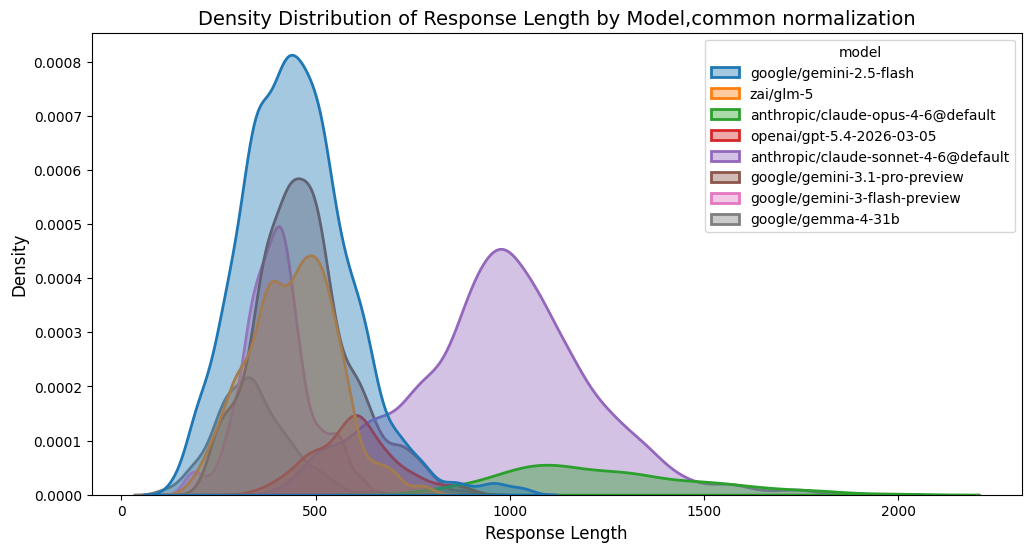

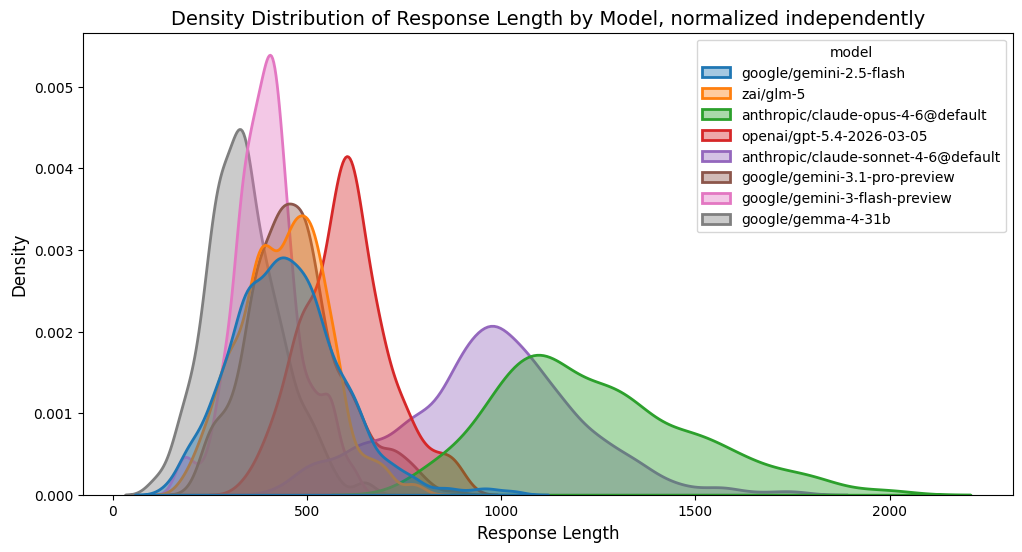

In [93]:
def plot_densities(common_norm=True,title='Density Distribution of Response Length by Model'):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))

    # Use hue='model' to separate the densities by model
    # fill=True adds shading under the curves
    # alpha sets the transparency of the shading
    sns.kdeplot(
        data=df, 
        x='response_length', 
        hue='model', 
        fill=True, 
        common_norm=common_norm, 
        alpha=0.4,
        linewidth=2
    )

    plt.title(title, fontsize=14)
    plt.xlabel('Response Length', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.show()
plot_densities(common_norm=True,title='Density Distribution of Response Length by Model,common normalization')
plot_densities(common_norm=False,title='Density Distribution of Response Length by Model, normalized independently')

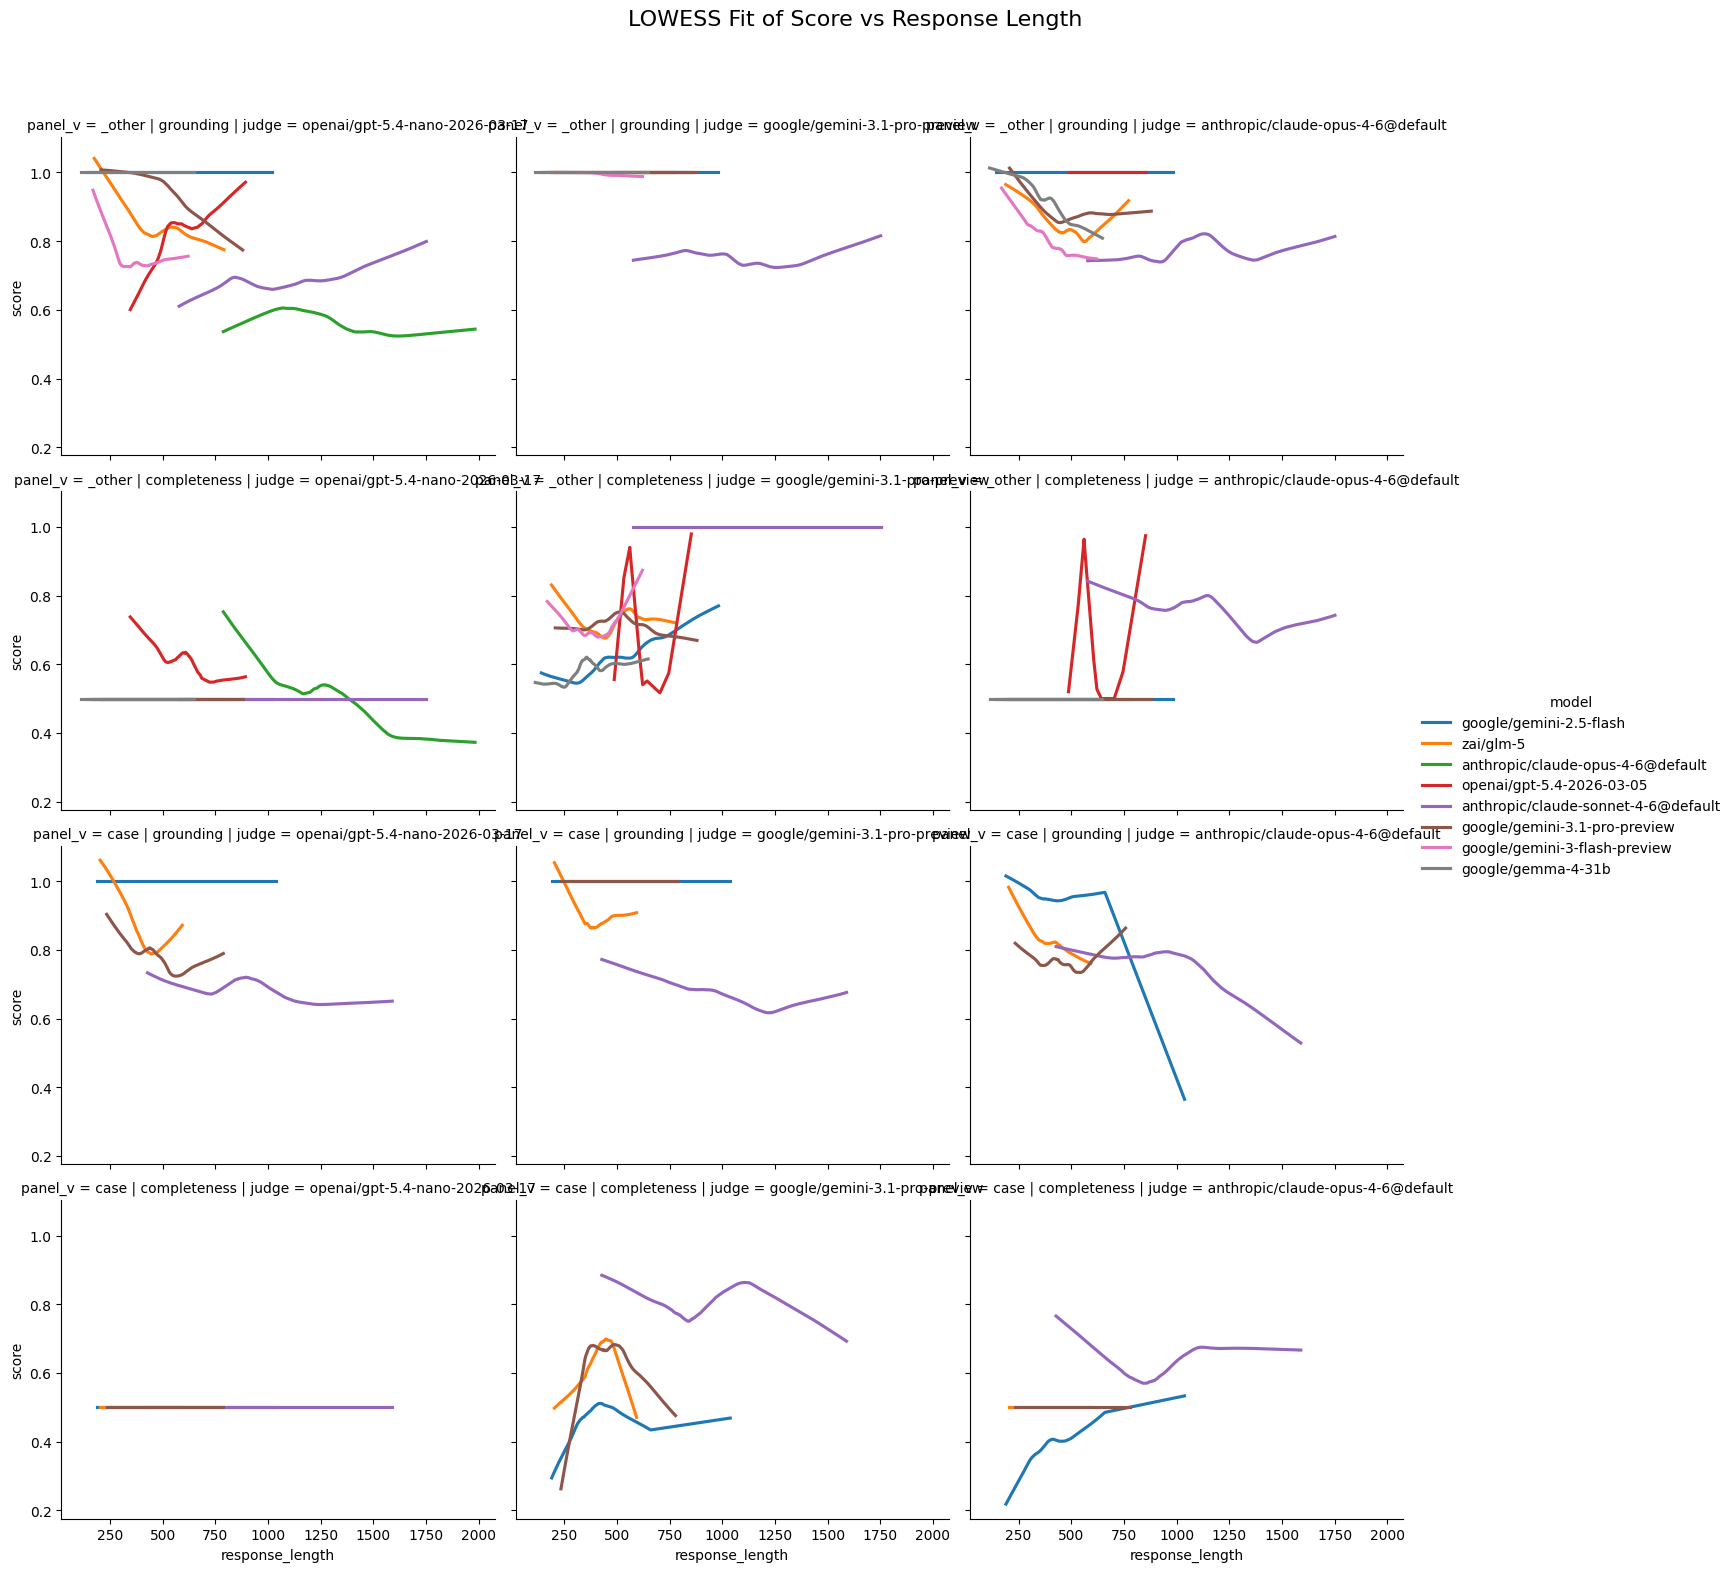

In [94]:
# lossless fit line plots 'score' vs. 'response_length', colored by 'model' , vertical panels by 'metric', vertical panels by 'judge'
import seaborn as sns
import matplotlib.pyplot as plt
df2=(df['judge'].value_counts().reset_index().query("count>1000").merge(df,on='judge',how='inner').assign(panel_v=lambda x:x['pt2'].astype(str) + " | " + x['metric'].astype(str) ))

# Create a grid of lowess fit lines
g = sns.lmplot(
    data=df2,
    x='response_length',
    y='score',
    hue='model',       # Colors the lines by 'model'
    row='panel_v',      # Creates vertical panels (rows) for each 'metric'
    col='judge',       # Creates horizontal panels (columns) for each 'judge'
    lowess=True,       # Uses a lowess smooth fit line
    scatter=False,     # Set to True if you also want to see the individual data points
    height=4,          # Adjust the height of each panel
    aspect=1.2         # Adjust the width-to-height ratio of each panel
)

# Optional: Add a main title and adjust layout
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('LOWESS Fit of Score vs Response Length', fontsize=16)

plt.show()


In [95]:
df.query("pt2=='_other' and metric== 'completeness' and judge.str.contains('opus') and model.str.contains('opus')")[['model','score']].describe()

,score
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [ ]:
df2=(df['judge'].value_counts().reset_index().query("count>1000").merge(df,on='judge',how='inner')


In [99]:
df2=df2['model'].value_counts().reset_index().query("count>1000").merge(df,on='model',how='inner')

In [101]:
import pandas as pd
import statsmodels.formula.api as smf

df2 = df2.query("response_length < 1500")
df2['response_length']=(df2['response_length']/100)-5


fit = smf.mixedlm(
    'score ~ response_length*C(metric)*C(model, Treatment(reference="google/gemini-2.5-flash"))'
    '+C(pt2) +C(judge, Treatment(reference="google/gemini-3.1-pro-preview"))'
    ,
    data=df2,
    groups=df2["sample_id"],
    re_formula="1",
).fit(reml=True, method="powell", maxiter=100000)


print(fit.summary())


                                                                       Mixed Linear Model Regression Results
Model:                                                       MixedLM                                          Dependent Variable:                                          score    
No. Observations:                                            10900                                            Method:                                                      REML     
No. Groups:                                                  358                                              Scale:                                                       0.0644   
Min. group size:                                             4                                                Log-Likelihood:                                              -843.2475
Max. group size:                                             71                                               Converged:                                               

In [102]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# 1. Define the range for the continuous variable
min_len = df2['response_length'].min()
max_len = df2['response_length'].max()
seq_len = np.linspace(min_len, max_len, 100) # 100 points for smooth lines

# 2. Get unique levels of the interacting categorical variables
metrics = df2['metric'].unique()
models = df2['model'].unique()

# 3. Create the Cartesian product of these variables
pred_data = list(itertools.product(seq_len, metrics, models))
pred_df = pd.DataFrame(pred_data, columns=['response_length', 'metric', 'model'])

# 4. Hold covariates constant (Crucial for isolating the interaction)
# Use your reference judge
pred_df['judge'] = "google/gemini-3.1-pro-preview" 
# Fix pt2 to its most common value (mode) or a specific reference
pred_df['pt2'] = df2['pt2'].mode()[0] 

# Note: statsmodels mixedlm predict() ignores random effects by default 
# when you pass new data, which is exactly what we want for population-level (fixed) effects.
pred_df['predicted_score'] = fit.predict(pred_df)

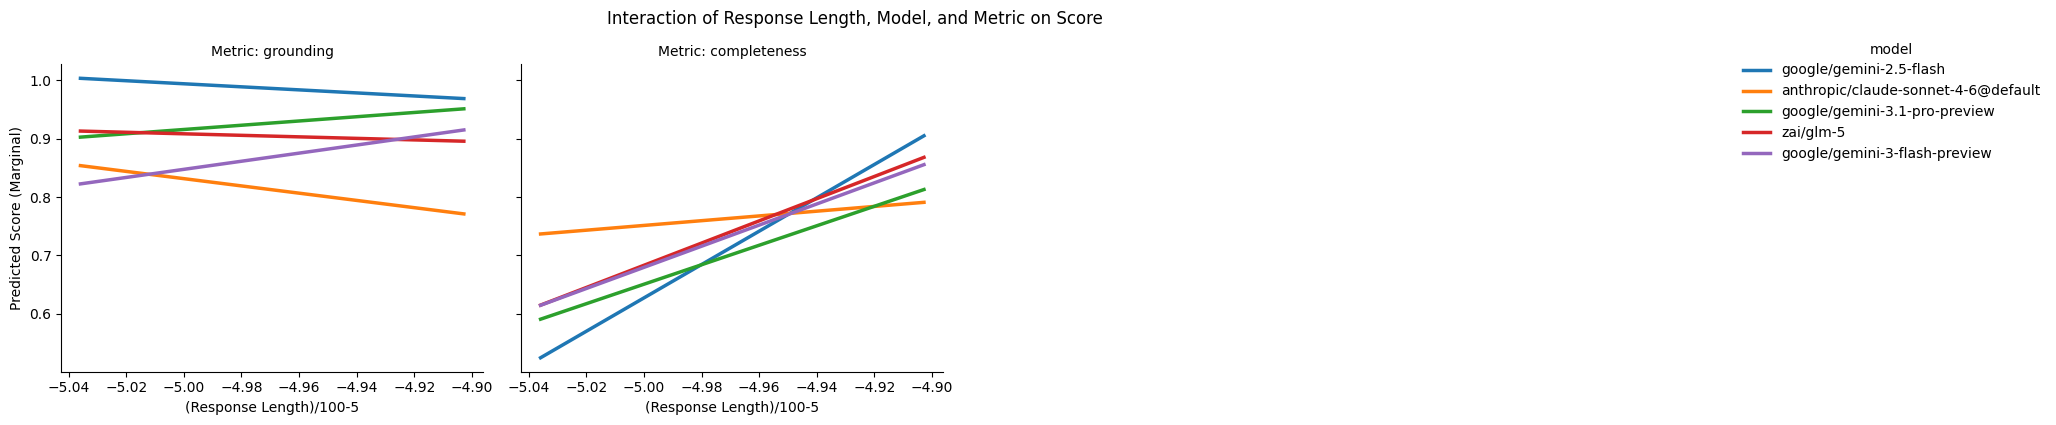

In [103]:
# Create the faceted plot
g = sns.relplot(
    data=pred_df,
    x='response_length',
    y='predicted_score',
    hue='model',
    col='metric',
    col_wrap=3,          # Adjust this based on how many metrics you have
    kind='line',
    linewidth=2.5,
    height=4,            # Height of each individual subplot
    aspect=1.2           # Width-to-height ratio of each subplot
)

# Formatting for readability
g.set_axis_labels("(Response Length)/100-5", "Predicted Score (Marginal)")
g.set_titles("Metric: {col_name}")
g.fig.suptitle("Interaction of Response Length, Model, and Metric on Score", y=1.05)

# Optional: Adjust legend
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

plt.show()

In [104]:
#pivot df with folder,record_id as idx and metric_judge as columns
col_index=['doi', 'sample_id', 'response_length', 'model']
df = (scores.assign(new_col_name=lambda x: x['metric'].astype(str) + ':' + x['judge'].astype(str))
    .pivot_table(index=col_index, columns='new_col_name', values='score', aggfunc='mean') # Pivot the DataFrame
    .reset_index()          # Flattens the multi-index created by pivot
    .rename_axis(None, axis=1) # Removes the 'new_col_name' label over the columns
)


In [105]:
# Keep columns that have at least 20% non-missing values
df = df.dropna(thresh=len(df) * 0.2, axis=1)
#keep rows  that have at least 20% non-missing values
df = df.dropna(thresh=len(df.columns) * 0.2, axis=0)

In [106]:
vars = [x for x in df.columns.tolist() if not x in col_index] 
print(f"vars: {vars}")

vars: ['completeness:anthropic/claude-opus-4-6@default', 'completeness:google/gemini-3.1-pro-preview', 'completeness:openai/gpt-5.4-nano-2026-03-17', 'grounding:anthropic/claude-opus-4-6@default', 'grounding:google/gemini-3.1-pro-preview', 'grounding:openai/gpt-5.4-nano-2026-03-17']


In [107]:
df = df.merge(records, left_on='doi' , right_on='doi', how='inner')


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# 1. Setup Mock Data
# X is a list of strings (e.g., tags, categories)
# Y is a multidimensional numeric array
#first 4 columns are Y targets, the last column is the text feature
Y = df[vars].values
Y=np.where(np.isnan(Y), np.nanmean(Y, axis=0), Y)
def semicolon_tokenizer(text):
    return [tag.strip() for tag in text.split(';') if tag.strip()]
vectorizer = CountVectorizer(tokenizer=semicolon_tokenizer, 
    token_pattern=None, 
    binary=True, 
    max_features=20)


In [109]:
import scipy.sparse as sp

# 1. Text features (Sparse Matrix)
X_text = vectorizer.fit_transform(df['pt'])
# Check the features
print("Detected Features (including multi-word names):")
print(vectorizer.get_feature_names_out())
feature_names = vectorizer.get_feature_names_out()
# 2. Categorical dummies (Dense 2D Array)
model_dummies = pd.get_dummies(df['model'], prefix='model')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# This will output a 2D array scaled to mean=0, variance=1
length_scaled = scaler.fit_transform(df[['response_length']])

# Stack with the scaled feature instead
X = sp.hstack((X_text, model_dummies.values, length_scaled), format='csr')


Detected Features (including multi-word names):
['case reports' 'clinical trial' 'comparative study' 'english abstract'
 'journal article' 'meta-analysis' 'multicenter study'
 'observational study' 'randomized controlled trial'
 "research support, non-u.s. gov't" 'retraction notice' 'review'
 'scoping review' 'systematic review' 'validation study'
 'video-audio media']


In [110]:
feature_names=feature_names.tolist()+model_dummies.columns.tolist()+['response_length']

Coefficient Matrix (Predictive Power of each string):
                                                case reports  clinical trial  \
completeness:anthropic/claude-opus-4-6@default     -0.118598        0.109974   
completeness:google/gemini-3.1-pro-preview         -0.107033        0.084438   
completeness:openai/gpt-5.4-nano-2026-03-17        -0.074498        0.048143   
grounding:anthropic/claude-opus-4-6@default        -0.046853        0.213899   
grounding:google/gemini-3.1-pro-preview            -0.033259        0.098397   
grounding:openai/gpt-5.4-nano-2026-03-17           -0.035427        0.170414   

                                                comparative study  \
completeness:anthropic/claude-opus-4-6@default           0.016104   
completeness:google/gemini-3.1-pro-preview              -0.014200   
completeness:openai/gpt-5.4-nano-2026-03-17              0.093006   
grounding:anthropic/claude-opus-4-6@default              0.062729   
grounding:google/gemini-3.1-pro-preview 

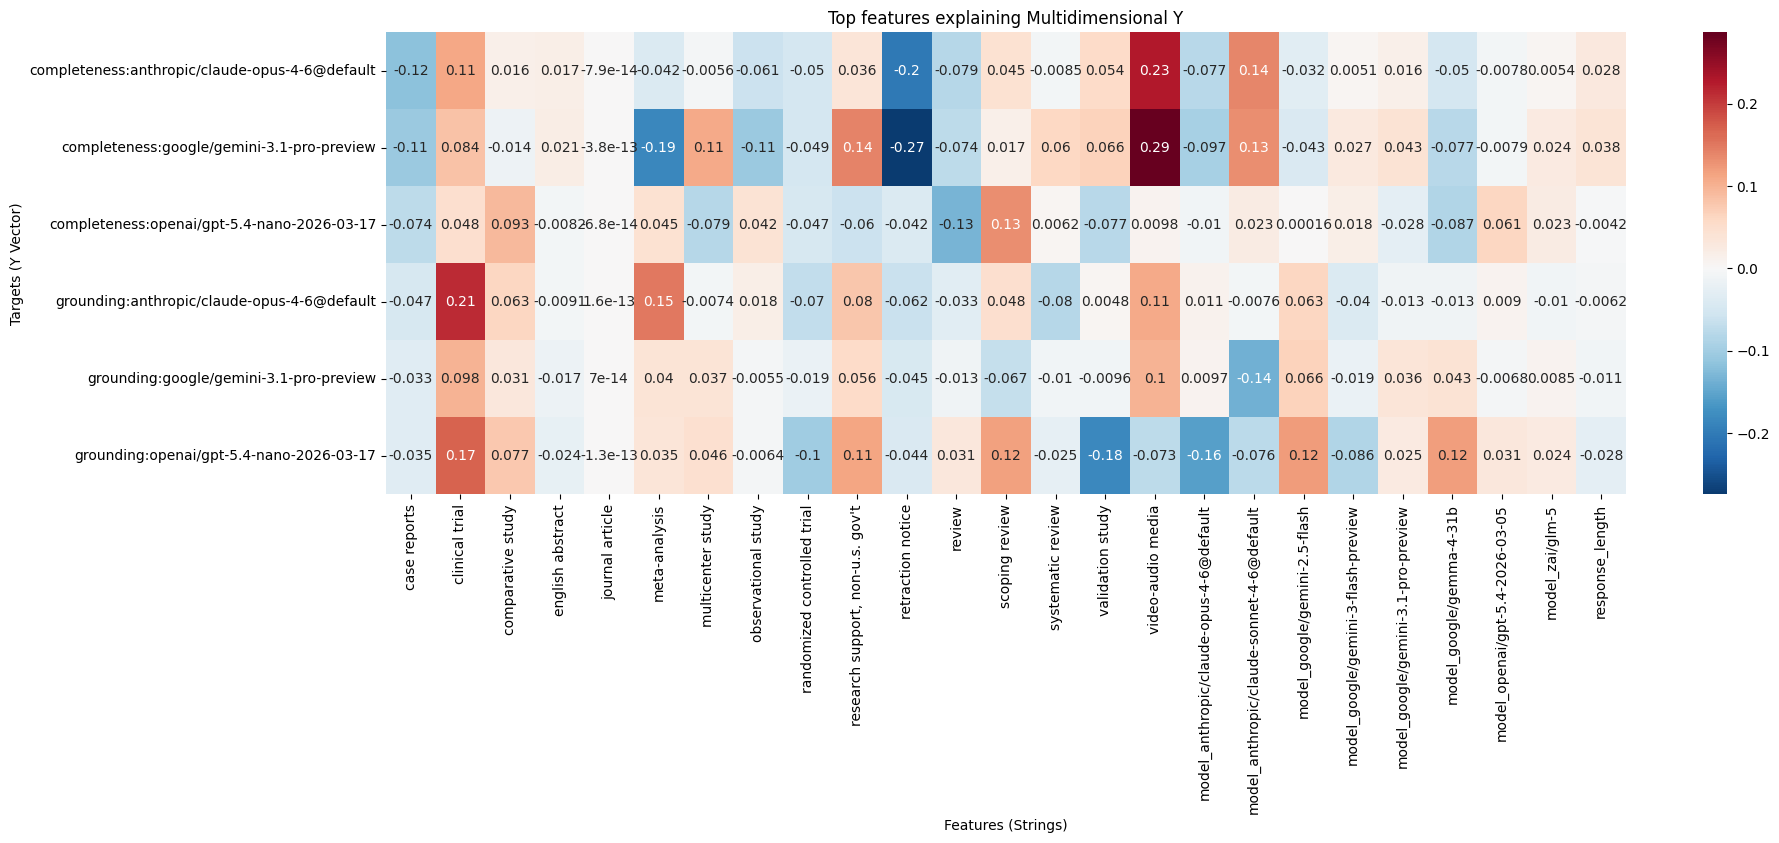

In [111]:



# 3. Fit the Multi-Output Model
# Ridge regression is highly interpretable via coefficients
model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(X, Y)

# 4. Extract Interpretability (Coefficients)
# coefficients shape: (n_targets, n_features)
coefficients = np.array([est.coef_ for est in model.estimators_])

coef_df = pd.DataFrame(
    coefficients, 
    columns=feature_names, 
    index=vars
)

print("Coefficient Matrix (Predictive Power of each string):")
print(coef_df)

# 5. Visualize the relationships
plt.figure(figsize=(20, 6))
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0)
plt.title("Top features explaining Multidimensional Y")
plt.xlabel("Features (Strings)")
plt.ylabel("Targets (Y Vector)")
plt.show()

In [119]:
coef_df.abs().sum().to_frame(name='coef_absolute_sum').merge(pd.DataFrame(
    {'fraction_non_zero': X.getnnz(axis=0) / X.shape[0]}, 
    index=feature_names
),left_index=True, right_index=True).sort_values(by='coef_absolute_sum', ascending=False)



,coef_absolute_sum,fraction_non_zero
video-audio media,8.611882e-01,0.001943
retraction notice,6.680373e-01,0.000971
clinical trial,5.857188e-01,0.001943
model_anthropic/claude-sonnet-4-6@default,5.156991e-01,0.220981
"research support, non-u.s. gov't",4.842382e-01,0.007285
meta-analysis,4.431105e-01,0.031569
case reports,4.297458e-01,0.258864
scoping review,4.212812e-01,0.003885
model_google/gemma-4-31b,3.906540e-01,0.048567
validation study,3.849926e-01,0.001943


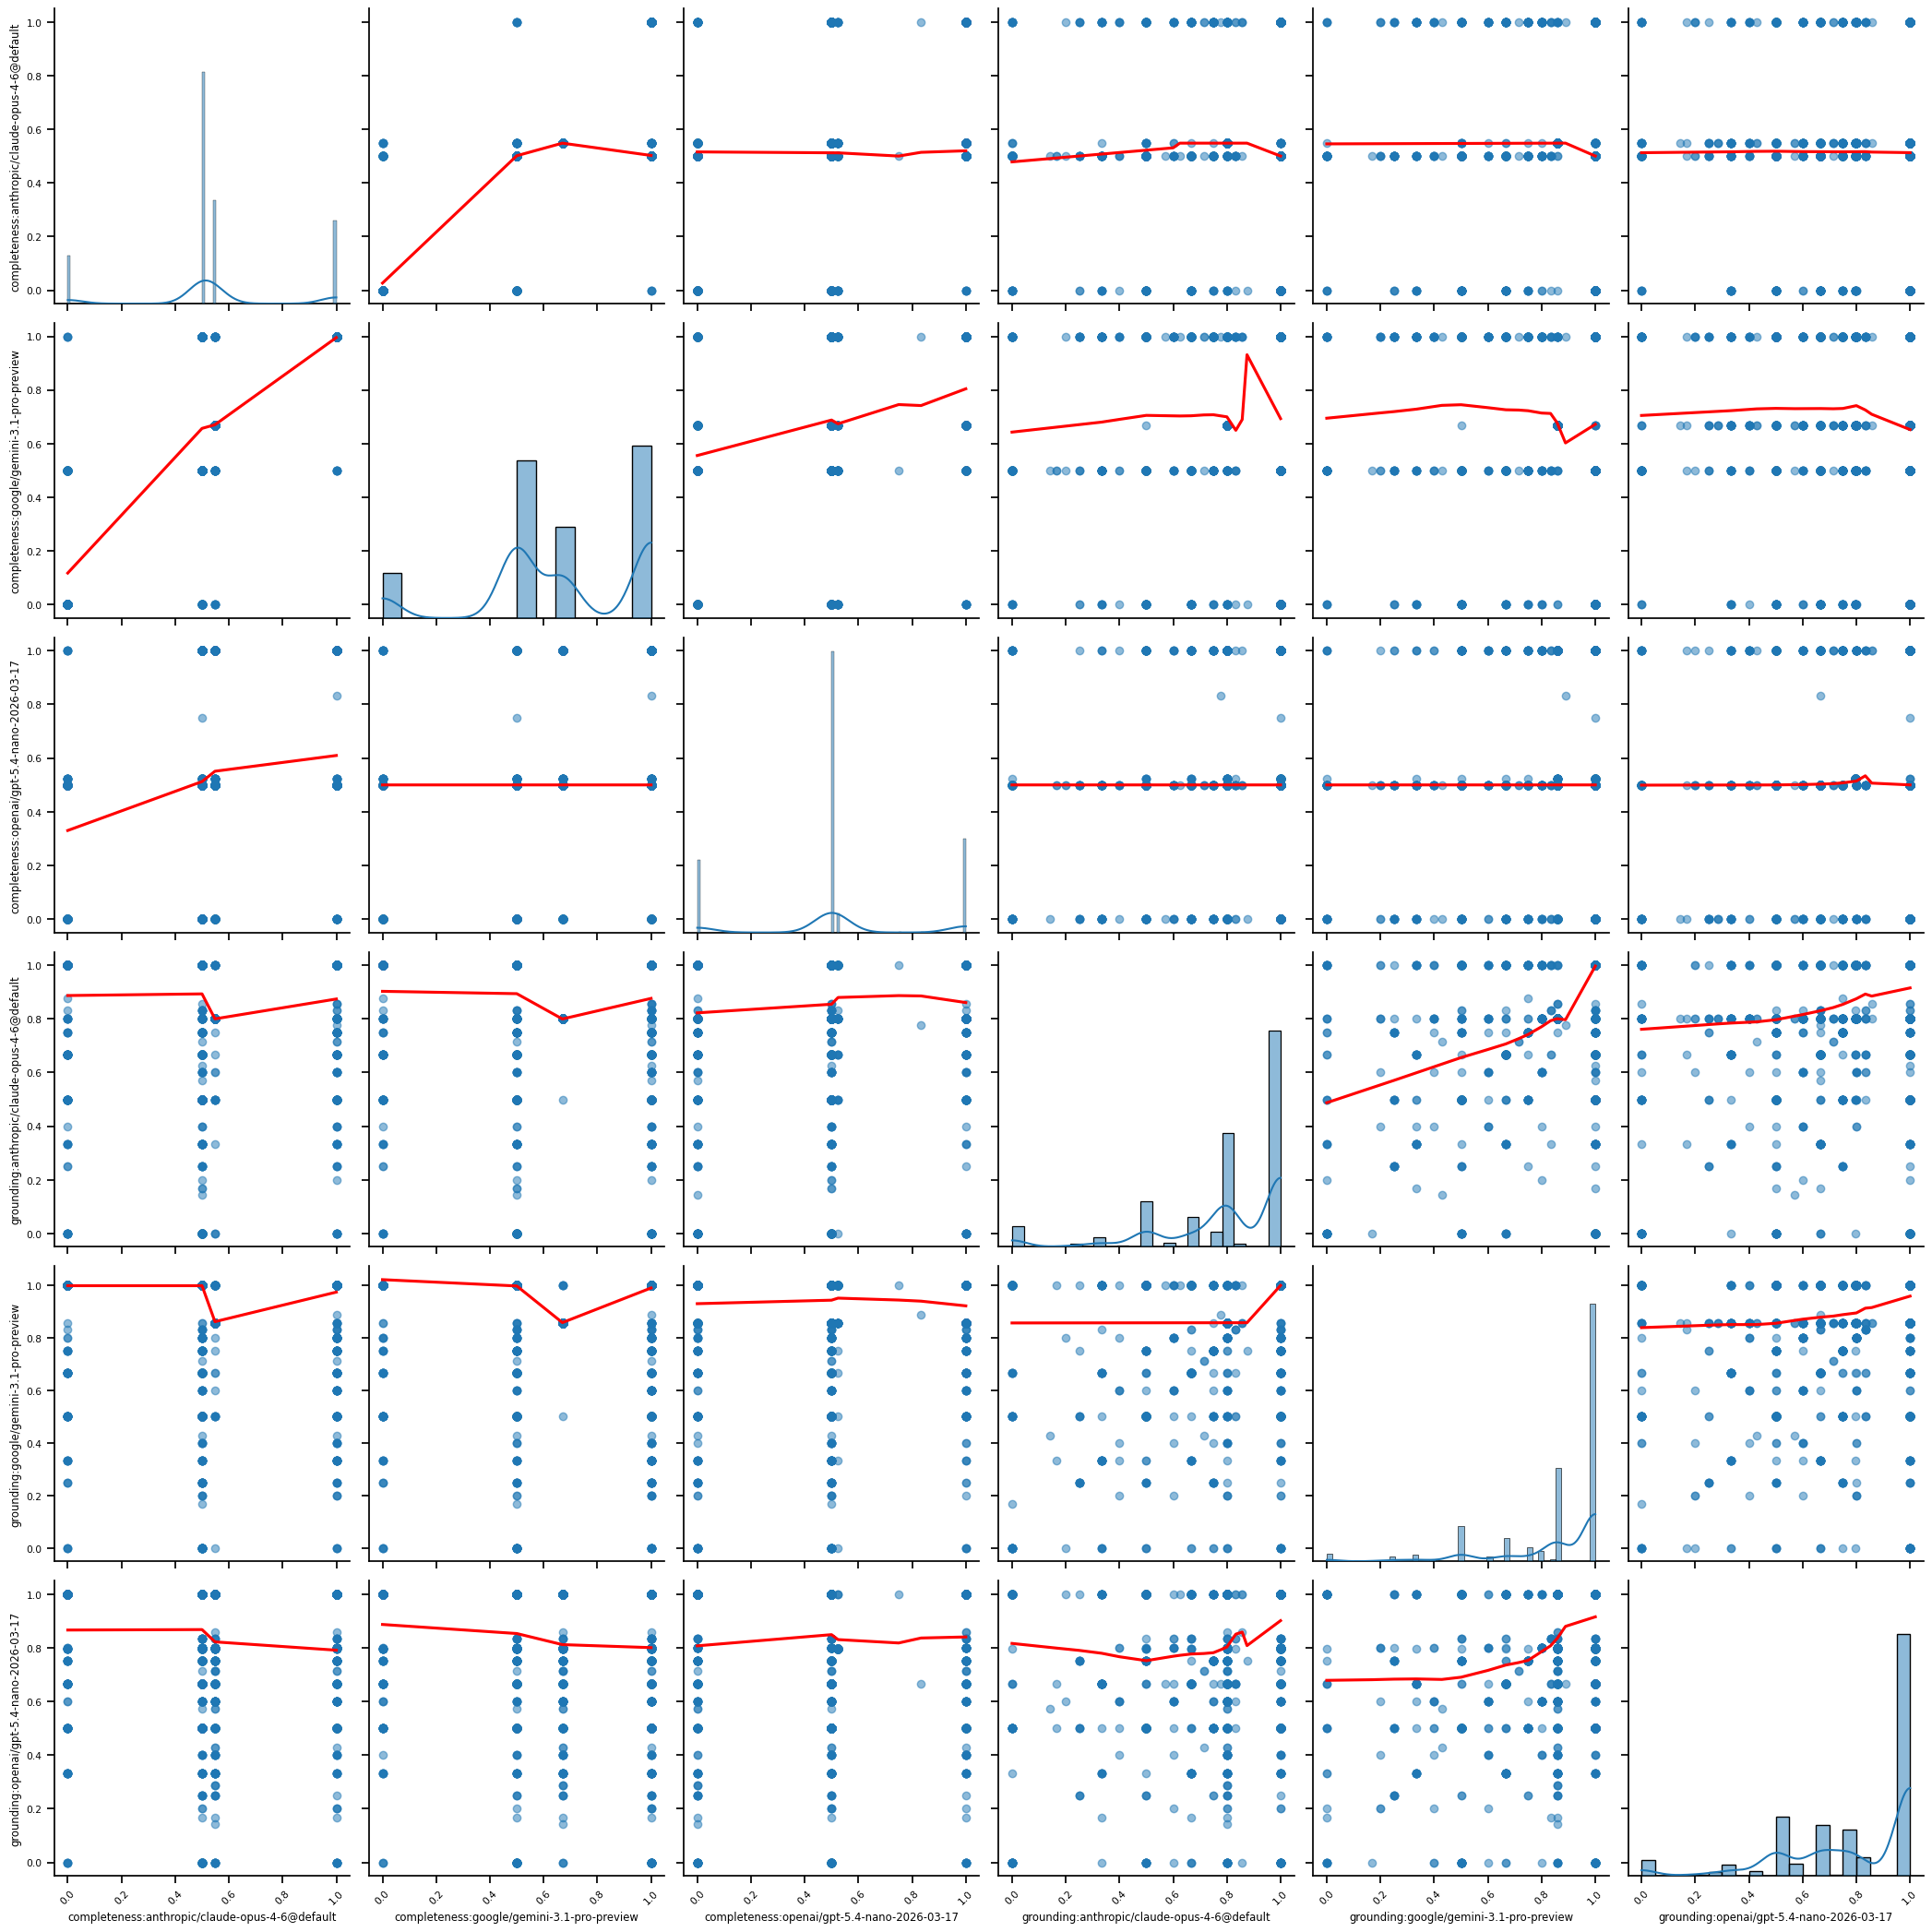

In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(Y, columns=vars)

# 1. [FONT FIX] Scale down ALL fonts globally by modifying font_scale (default is 1.0)
sns.set_context("notebook", font_scale=0.7)

# 2. [SIZE FIX] Increase 'height' (Default is usually 2.5). 
# This is the physical size of EACH panel. E.g., height=4 on a 3x3 matrix makes a 12x12 figure.
g = sns.PairGrid(df, height=3.5) 

# Map your plots
g.map_offdiag(sns.regplot, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
g.map_diag(sns.histplot, kde=True)

# 3. [OPTIONAL ROTATION] Rotate labels just to be safe
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(axis='x', rotation=45)

g.fig.tight_layout()
plt.show()

# 4. (Optional) Reset context back to normal after the plot so it doesn't affect future plots
sns.set_context("notebook", font_scale=1.0)
